# 412024030 - Davidson Rafael Krisman Nugroho - Pengolahan Citra

# Praktikum Pengolahan Citra - Sub-CPMK 3
## Ruang Warna, Transformasi Geometrik, dan Penghitung Objek

**Tujuan:** mengubah citra ke HSV, membuat *mask* warna, menghitung objek terpisah, lalu menguji hasilnya setelah transformasi geometrik.

Alur utama: BGR -> HSV -> *mask* -> komponen objek -> hitung dan anotasi.

## Alur sesi

- Ulasan singkat BGR dan RGB
- HSV dan *masking*
- Penghitungan komponen
- Translasi, rotasi, *scaling*, dan *flip*
- Latihan dan mini-proyek

In [1]:
import os
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 11
print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)


OpenCV: 5.0.0
NumPy : 2.1.3


In [2]:
ASSET_DIR = Path("assets/subcpmk3")
controlled_path = ASSET_DIR / "objek_warna_terkontrol.png"
challenge_path = ASSET_DIR / "objek_warna_tantangan.png"

def make_demo_scene(height=540, width=720):
    """Fallback scene so the notebook still runs after a fresh Colab upload."""
    canvas = np.full((height, width, 3), 235, dtype=np.uint8)  # BGR light gray
    centers = [(130, 120), (360, 120), (590, 120),
               (130, 270), (360, 270), (590, 270),
               (130, 420), (360, 420), (590, 420)]
    colors = [(40, 190, 60)] * 3 + [(220, 90, 30)] * 3 + [(20, 120, 230)] * 3
    for center, color in zip(centers, colors):
        cv2.circle(canvas, center, 70, color, -1)
        cv2.circle(canvas, center, 70, (30, 30, 30), 3)
    return canvas

if controlled_path.exists():
    img_bgr = cv2.imread(str(controlled_path))
    source_name = controlled_path.name
else:
    img_bgr = make_demo_scene()
    source_name = "fallback synthetic scene"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print("Sumber:", source_name, "| shape:", img_bgr.shape)


Sumber: fallback synthetic scene | shape: (540, 720, 3)


In [3]:
def show_rgb(image_rgb, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(image_rgb)
    ax.set_title(title)
    ax.axis("off")
    return ax

def show_bgr(image_bgr, title="", ax=None):
    return show_rgb(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), title, ax)


## 1. Mengingat kembali urutan kanal

OpenCV membaca citra berwarna sebagai BGR. Gunakan RGB hanya ketika menampilkan dengan Matplotlib.

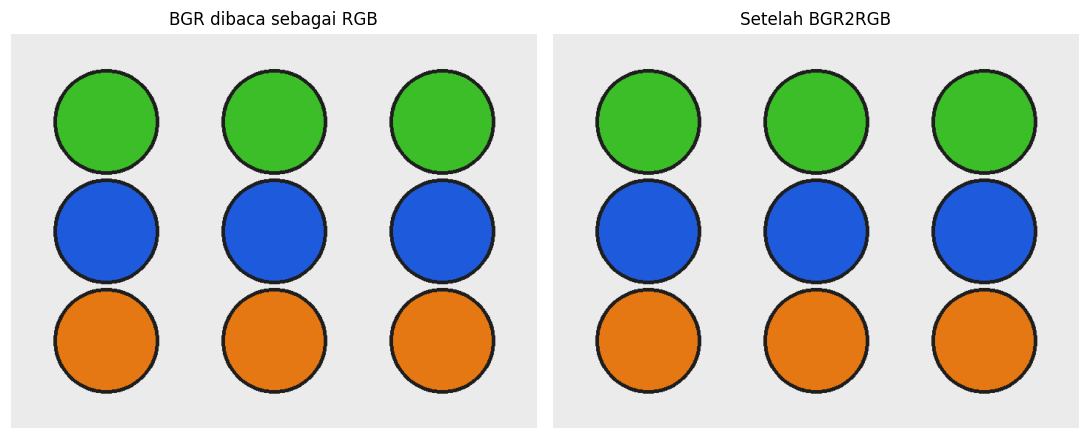

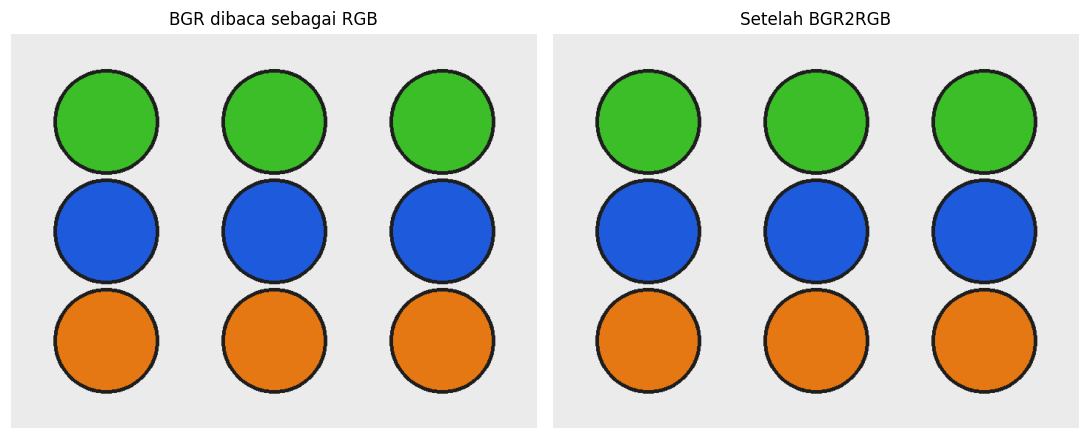

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
show_bgr(img_bgr, "BGR dibaca sebagai RGB", ax[0])
show_rgb(img_rgb, "Setelah BGR2RGB", ax[1])
plt.tight_layout()
display(plt.gcf())


## 2. Ruang warna

HSV memisahkan jenis warna, kejenuhan, dan tingkat terang. Pada OpenCV, H berada pada 0-179, S dan V pada 0-255.

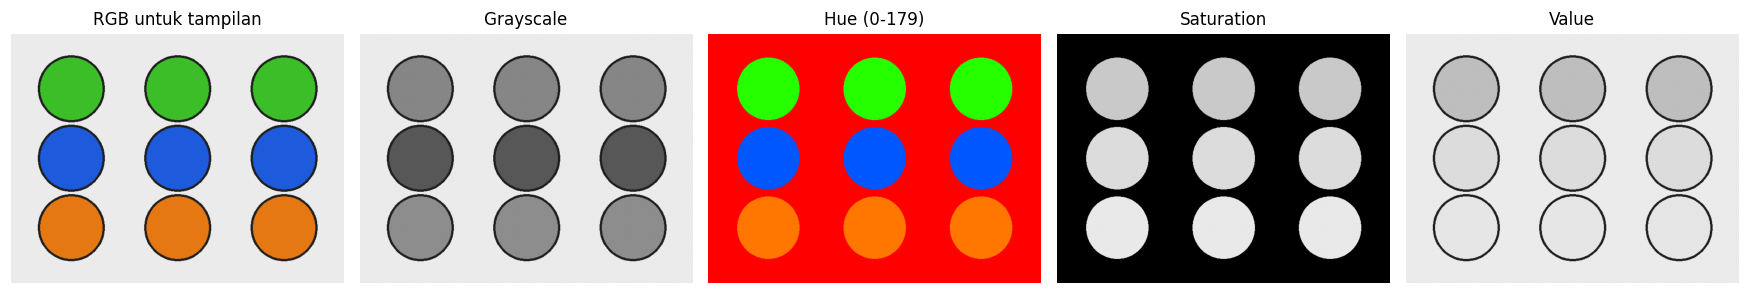

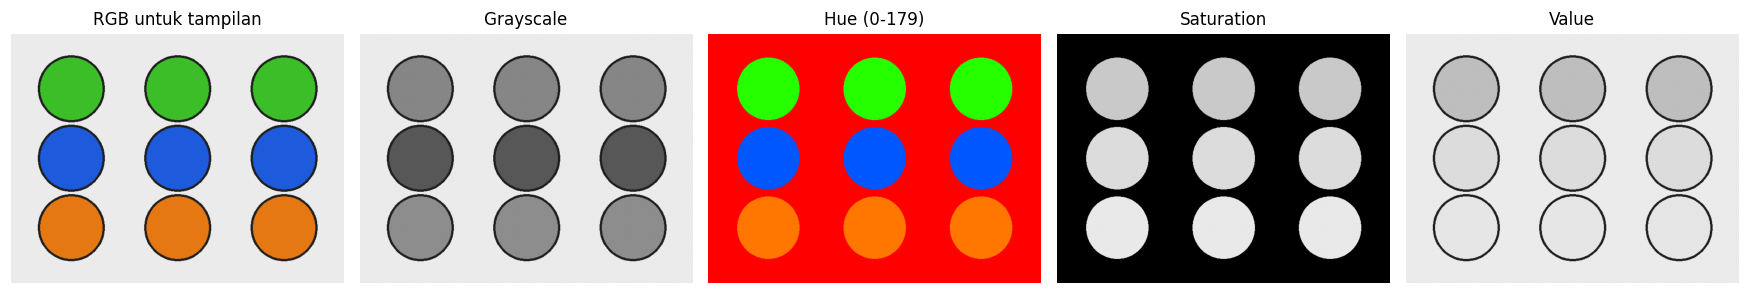

In [5]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

fig, ax = plt.subplots(1, 5, figsize=(16, 3.4))
show_rgb(img_rgb, "RGB untuk tampilan", ax[0])
ax[1].imshow(gray, cmap="gray", vmin=0, vmax=255); ax[1].set_title("Grayscale"); ax[1].axis("off")
ax[2].imshow(H, cmap="hsv", vmin=0, vmax=179); ax[2].set_title("Hue (0-179)"); ax[2].axis("off")
ax[3].imshow(S, cmap="gray", vmin=0, vmax=255); ax[3].set_title("Saturation"); ax[3].axis("off")
ax[4].imshow(V, cmap="gray", vmin=0, vmax=255); ax[4].set_title("Value"); ax[4].axis("off")
plt.tight_layout()
display(plt.gcf())


## 3. Membuat *mask* warna

`cv2.inRange` mempertahankan piksel yang berada di antara batas bawah dan batas atas.

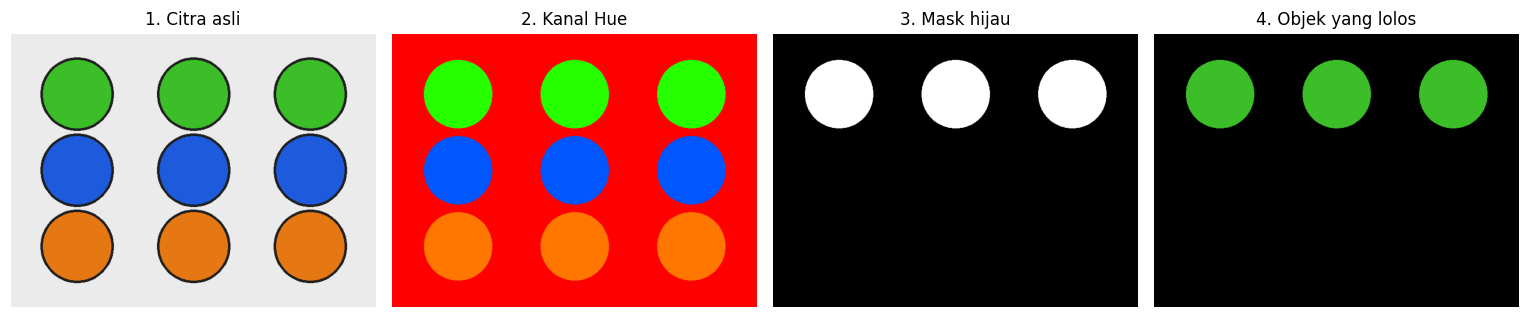

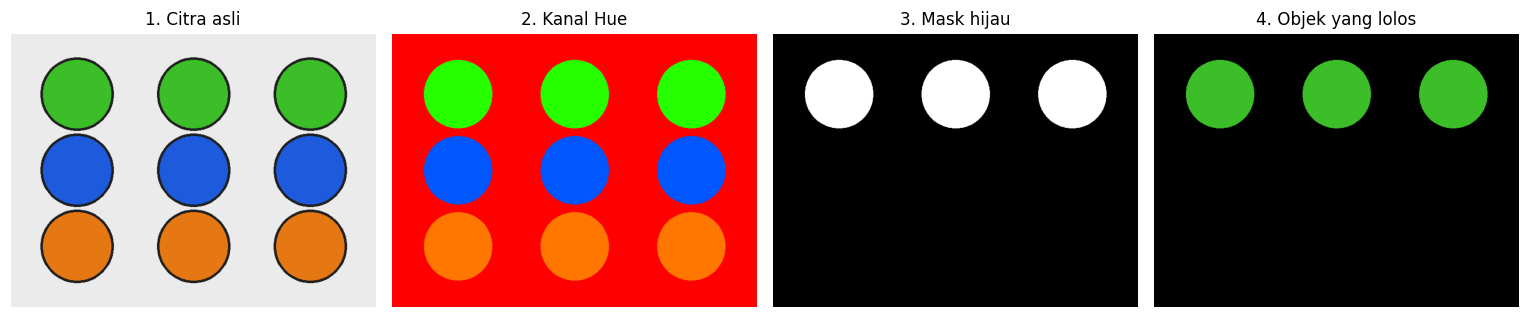

In [6]:
# Rentang hijau untuk citra contoh. H pada OpenCV berada di 0-179.
lower_green = np.array([45, 80, 50], dtype=np.uint8)
upper_green = np.array([85, 255, 255], dtype=np.uint8)
mask_green = cv2.inRange(hsv, lower_green, upper_green)
result_green = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_green)

fig, ax = plt.subplots(1, 4, figsize=(14, 3.5))
show_rgb(img_rgb, "1. Citra asli", ax[0])
ax[1].imshow(hsv[:, :, 0], cmap="hsv", vmin=0, vmax=179); ax[1].set_title("2. Kanal Hue"); ax[1].axis("off")
ax[2].imshow(mask_green, cmap="gray", vmin=0, vmax=255); ax[2].set_title("3. Mask hijau"); ax[2].axis("off")
show_bgr(result_green, "4. Objek yang lolos", ax[3])
plt.tight_layout()
display(plt.gcf())


## 4. Menghitung objek

Setiap wilayah putih yang terpisah menjadi calon objek. Label 0 adalah latar belakang, sehingga tidak ikut dihitung.

Objek hijau: 3
Luas objek: [14331, 14331, 14331]


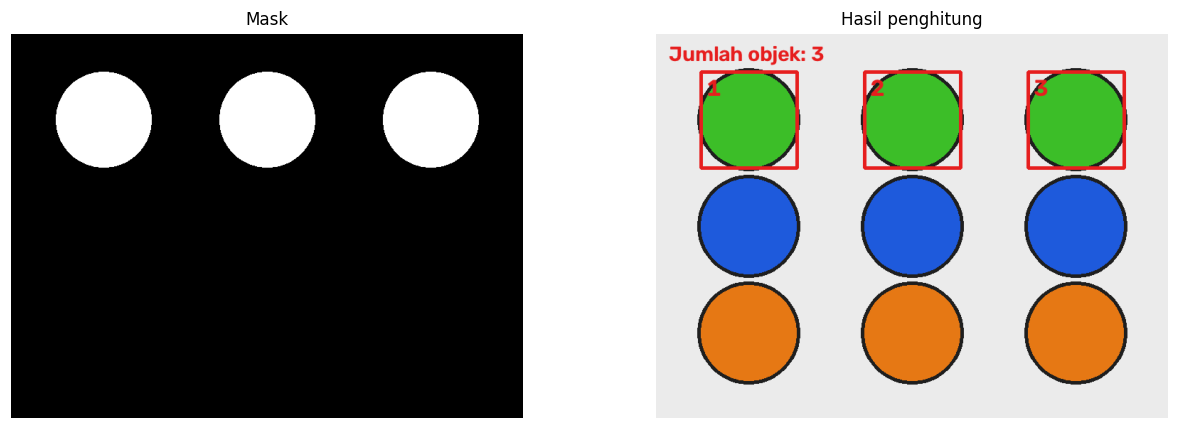

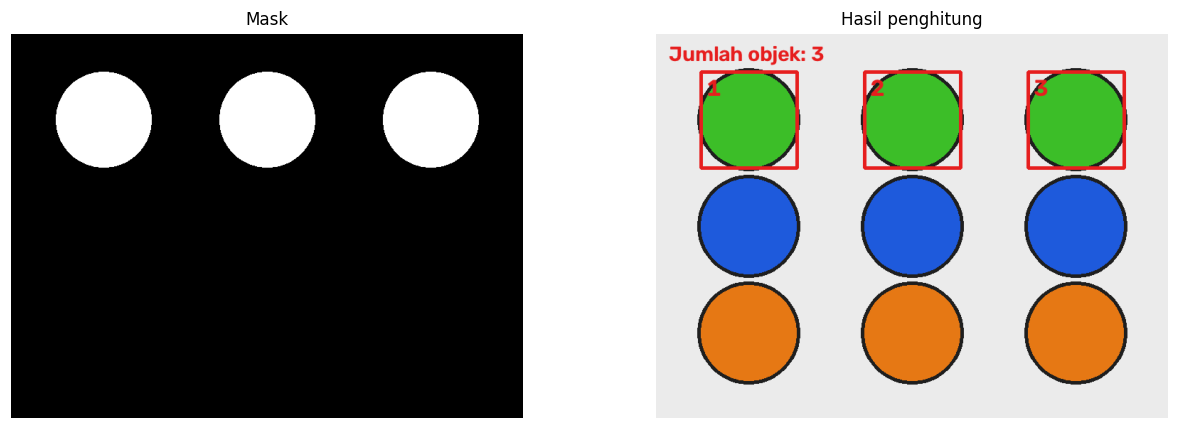

In [7]:
def count_components(mask, min_area=500):
    """Hitung wilayah putih yang cukup luas pada mask biner."""
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )
    objects = []
    for label in range(1, n_labels):  # label 0 adalah latar belakang
        x, y, w, h, area = stats[label]
        if area >= min_area:
            objects.append({
                "label": int(label),
                "x": int(x), "y": int(y), "w": int(w), "h": int(h),
                "area": int(area),
                "centroid": tuple(np.round(centroids[label], 1)),
            })
    return objects

def annotate_objects(image_bgr, objects, color=(30, 30, 230)):
    output = image_bgr.copy()
    for idx, obj in enumerate(objects, start=1):
        x, y, w, h = obj["x"], obj["y"], obj["w"], obj["h"]
        cv2.rectangle(output, (x, y), (x + w, y + h), color, 3)
        cv2.putText(output, str(idx), (x + 8, y + 34),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3, cv2.LINE_AA)
    cv2.putText(output, f"Jumlah objek: {len(objects)}", (18, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 3, cv2.LINE_AA)
    return output

objects_green = count_components(mask_green, min_area=500)
annotated_green = annotate_objects(img_bgr, objects_green)
print("Objek hijau:", len(objects_green))
print("Luas objek:", [obj["area"] for obj in objects_green])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(mask_green, cmap="gray"); ax[0].set_title("Mask"); ax[0].axis("off")
show_bgr(annotated_green, "Hasil penghitung", ax[1])
plt.tight_layout()
display(plt.gcf())


## Kasus khusus: warna merah

Merah berada di dekat kedua ujung skala hue sehingga biasanya memerlukan dua *mask* yang digabungkan.

In [8]:
def red_mask(hsv_image):
    """Merah melewati batas skala hue, jadi perlu dua rentang."""
    lower_1 = np.array([0, 80, 50], dtype=np.uint8)
    upper_1 = np.array([10, 255, 255], dtype=np.uint8)
    lower_2 = np.array([170, 80, 50], dtype=np.uint8)
    upper_2 = np.array([179, 255, 255], dtype=np.uint8)
    mask_1 = cv2.inRange(hsv_image, lower_1, upper_1)
    mask_2 = cv2.inRange(hsv_image, lower_2, upper_2)
    return cv2.bitwise_or(mask_1, mask_2)


## 5. Transformasi geometrik

Transformasi mengubah posisi atau ukuran piksel, bukan identitas warna objek. Interpolasi dapat membuat tepi objek menghasilkan nilai campuran.

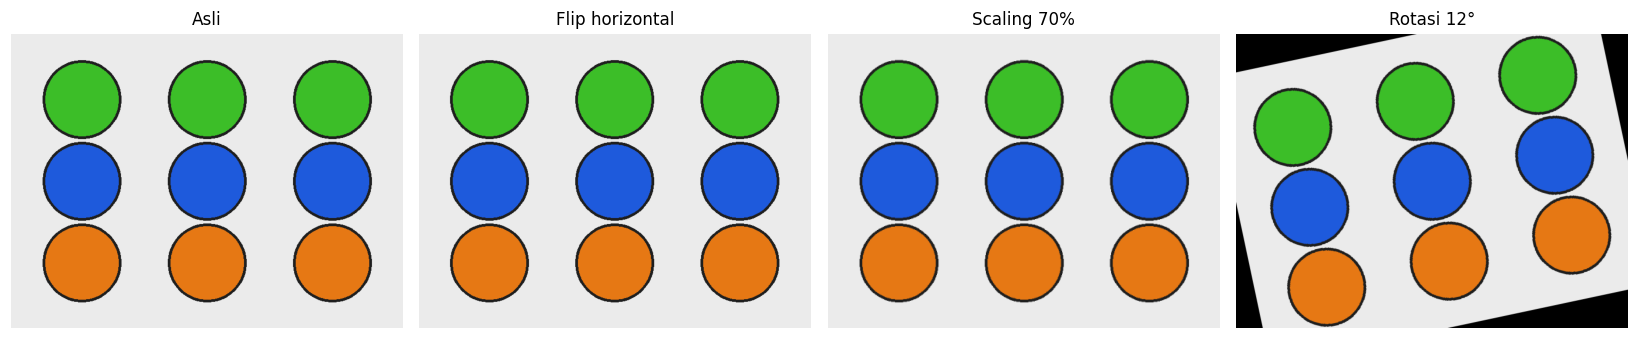

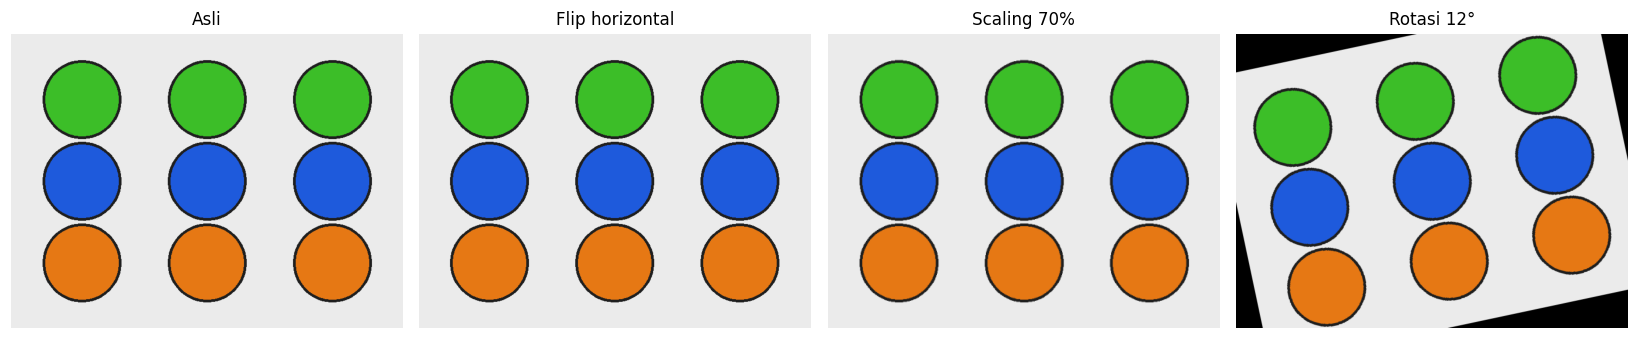

In [9]:
def transform_examples(image_bgr):
    h, w = image_bgr.shape[:2]
    flipped = cv2.flip(image_bgr, 1)
    scaled = cv2.resize(image_bgr, None, fx=0.70, fy=0.70, interpolation=cv2.INTER_AREA)
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, 12, 1.0)
    rotated = cv2.warpAffine(image_bgr, matrix, (w, h), flags=cv2.INTER_LINEAR)
    return flipped, scaled, rotated

flipped, scaled, rotated = transform_examples(img_bgr)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.5))
show_bgr(img_bgr, "Asli", ax[0])
show_bgr(flipped, "Flip horizontal", ax[1])
show_bgr(scaled, "Scaling 70%", ax[2])
show_bgr(rotated, "Rotasi 12°", ax[3])
plt.tight_layout()
display(plt.gcf())


## 6. Menguji penghitung pada citra yang ditransformasi

In [10]:
def count_by_color(image_bgr, lower_hsv, upper_hsv, min_area=500):
    hsv_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_image, lower_hsv, upper_hsv)
    objects = count_components(mask, min_area=min_area)
    annotated = annotate_objects(image_bgr, objects)
    return {
        "count": len(objects),
        "mask": mask,
        "objects": objects,
        "annotated": annotated,
    }

for name, transformed in [("asli", img_bgr), ("flip", flipped), ("rotasi", rotated)]:
    out = count_by_color(transformed, lower_green, upper_green, min_area=500)
    print(name, "->", out["count"], "objek")


asli -> 3 objek
flip -> 3 objek
rotasi -> 3 objek


## Latihan 1

Ambil satu warna selain hijau. Tentukan rentang HSV dan periksa apakah *mask* hanya mengambil objek sasaran.

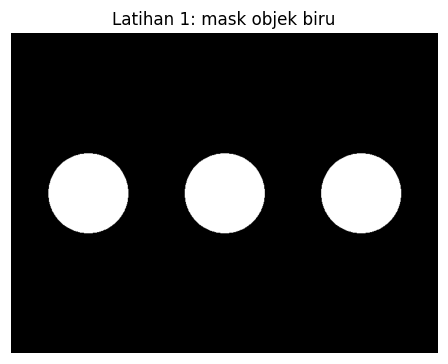

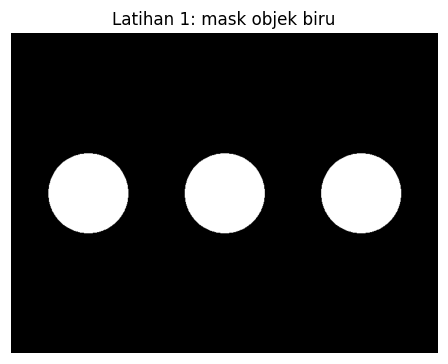

In [19]:
# Latihan 1: ubah rentang warna untuk mengambil objek biru.
# TODO: sesuaikan nilai H, S, dan V. Untuk contoh terkontrol, H biru berada sekitar 100-135.
lower_target = np.array([100, 100, 50], dtype=np.uint8)
upper_target = np.array([135, 255, 255], dtype=np.uint8)

mask_target = cv2.inRange(hsv, lower_target, upper_target)

plt.figure(figsize=(5, 4))
plt.imshow(mask_target, cmap="gray", vmin=0, vmax=255)
plt.title("Latihan 1: mask objek biru")
plt.axis("off")
display(plt.gcf())

## Latihan 2

Ubah sudut rotasi dan metode interpolasi. Catat perubahan bentuk citra dan dampaknya pada *mask*.

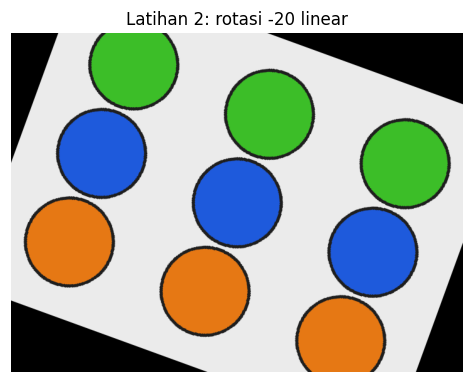

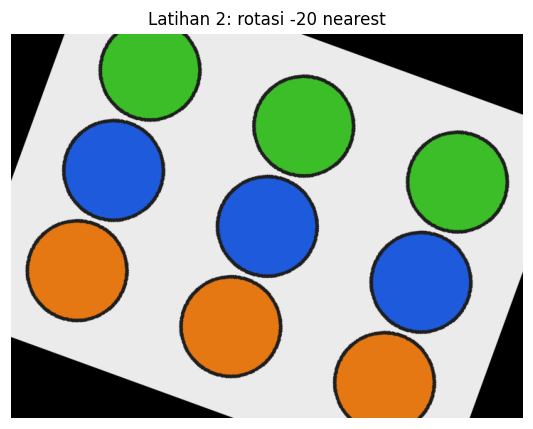

In [20]:
# Latihan 2: ganti sudut rotasi dan interpolation.
# TODO: coba sudut -20 atau 25, lalu bandingkan INTER_NEAREST dan INTER_LINEAR.
angle = -20
center = (img_bgr.shape[1] // 2, img_bgr.shape[0] // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
hasil_linear = cv2.warpAffine(img_bgr, M, (img_bgr.shape[1], img_bgr.shape[0]),
                              flags=cv2.INTER_LINEAR)
hasil_nearest = cv2.warpAffine(img_bgr, M, (img_bgr.shape[1], img_bgr.shape[0]),
                              flags=cv2.INTER_LINEAR)
show_bgr(hasil_linear, "Latihan 2: rotasi -20 linear")
show_bgr(hasil_nearest, "Latihan 2: rotasi -20 nearest")
plt.tight_layout()
# display(plt.gcf())


saat dirotasi -20 menghasilkan tampilan yang berbeda karna pakai motede interpolasi yang beda untuk nentuin piksel baru.

inter_nearest ambi nilai dari piksel terdekat hingga prosesnya sederhana tapi hasil rotasi gak terlihat kasar dan bergerigi
inter_linear menghitung nilai piksel berdasarkan piksel2 di sekitarnya ngehasilin citra yang lebih hasil terutama di bagian tepi objek dan garis diagonal

jadi inter_linear ngasih hasil visual yang lebih baik dari pada inter_nearest untuk transformasi seperti rotasi

## Latihan 3

Ubah `min_area` sampai bintik kecil tidak ikut dihitung. Jangan mengubah citra asli.

Jumlah objek: 3


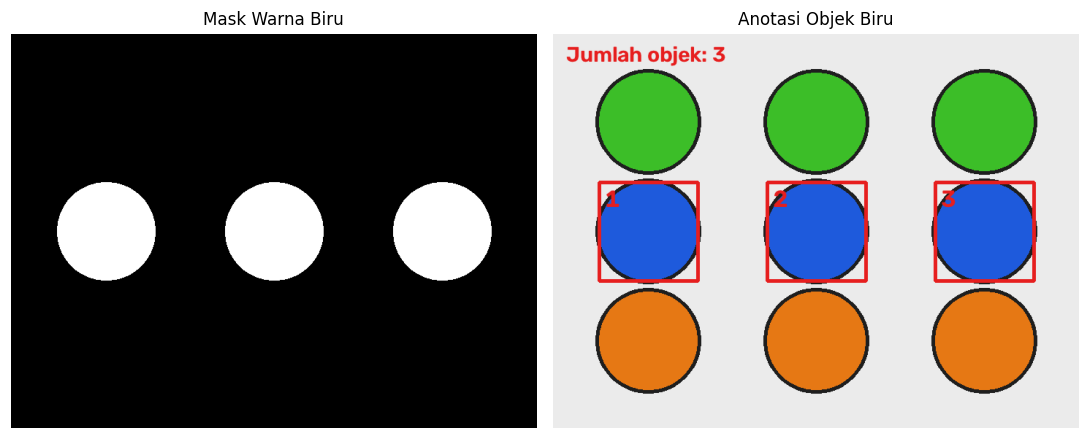

In [21]:
# Latihan 3: menghitung objek berwarna biru

# Rentang HSV untuk warna biru
lower_target = np.array([100, 100, 50], dtype=np.uint8)
upper_target = np.array([135, 255, 255], dtype=np.uint8)

# Objek dengan luas di bawah 500 piksel dianggap noise
min_area = 500

hasil_latihan = count_by_color(
    img_bgr,
    lower_target,
    upper_target,
    min_area=min_area
)

print("Jumlah objek:", hasil_latihan["count"])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(hasil_latihan["mask"], cmap="gray")
ax[0].set_title("Mask Warna Biru")
ax[0].axis("off")

show_bgr(
    hasil_latihan["annotated"],
    "Anotasi Objek Biru",
    ax[1]
)

plt.tight_layout()

## Mini-proyek

1. Pilih satu warna sasaran pada citra contoh atau foto sendiri.
2. Isi `lower_target` dan `upper_target` berdasarkan kanal HSV.
3. Hitung objek dengan `count_by_color`.
4. Uji ulang pada citra yang sudah di-*flip* atau diputar.
5. Kumpulkan notebook yang sudah dijalankan, tiga visual utama, jumlah objek, dan dua paragraf analisis.

Pertanyaan refleksi:

- Mengapa batas HSV yang terlalu lebar dapat menghitung latar belakang sebagai objek?
- Mengapa jumlah objek bisa berubah setelah rotasi atau perubahan ukuran?


Jumlah objek sasaran: 3


<Axes: title={'center': 'Hasil mini-proyek'}>

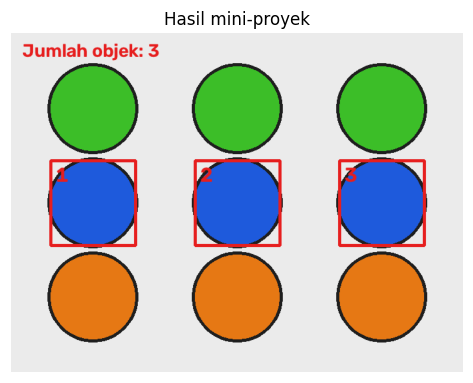

In [24]:
lower_target = np.array([100, 100, 50], dtype=np.uint8)
upper_target = np.array([135, 255, 255], dtype=np.uint8)

warna_sasaran = count_by_color(
    img_bgr,
    lower_target,
    upper_target,
    min_area=500
)

print("Jumlah objek sasaran:", warna_sasaran["count"])
show_bgr(warna_sasaran["annotated"], "Hasil mini-proyek")

Pada mini-proyek ini saya pilih warna biru sebagai warna sasaran dengan rentang HSV [100, 100, 50] sampai [135, 255, 255]. Rentang HSV ini dipakai buat misahin objek warna biru dari warna lainnya. Kalau batas HSV yang dipakai terlalu lebar, warna lain yang punya nilai HSV mirip bisa ikut masuk ke dalam mask. Akibatnya bagian background atau noise bisa dianggap sebagai objek juga, jadi jumlah objek yang terhitung bisa lebih banyak dari yang sebenarnya.

Pengujian juga dilakukan pada citra yang sudah di-flip dan dirotasi. Saat di-flip jumlah objek biasanya tetap karena yang berubah cuma posisi objeknya. Tapi saat dirotasi hasilnya bisa berbeda karena ada proses interpolasi untuk nentuin nilai piksel baru. Rotasi bisa bikin bentuk tepi dan nilai beberapa piksel berubah, jadi hasil deteksi objek juga bisa ikut berubah. Begitu juga kalau ukuran citra diubah, luas objek juga ikut berubah. Karena ada min_area sebagai batas minimum luas objek, objek yang ukurannya jadi terlalu kecil bisa gak dihitung lagi. Jadi jumlah objek setelah rotasi atau perubahan ukuran bisa aja berbeda dari citra awal.

## Rubrik singkat

- Mask warna tepat: 25%
- Penghitungan dan filter luas: 30%
- Transformasi geometrik: 20%
- Visualisasi: 10%
- Analisis keberhasilan atau kegagalan: 15%
